In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math
from models.unet import UNet
from utils import strided_ddim_sample, check_posterior_logic, verify_training_inputs, check_noise_correlation, visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess
from models.mnistfe import MNISTFeatureExtractor
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import polynomial_kernel

In [2]:
EPOCHS = 50
L = 1000
NUM_EVAL_SAMPLES = 10000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=4)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH, shuffle=False, num_workers=4)

In [4]:
model = UNet()
model.load_state_dict(torch.load("stats_models/lin_model_weights.pth", map_location=device))
model = model.to(device)
model.eval()

diff = DiffusionProcess(1000, device)

# 64 Sample Grid

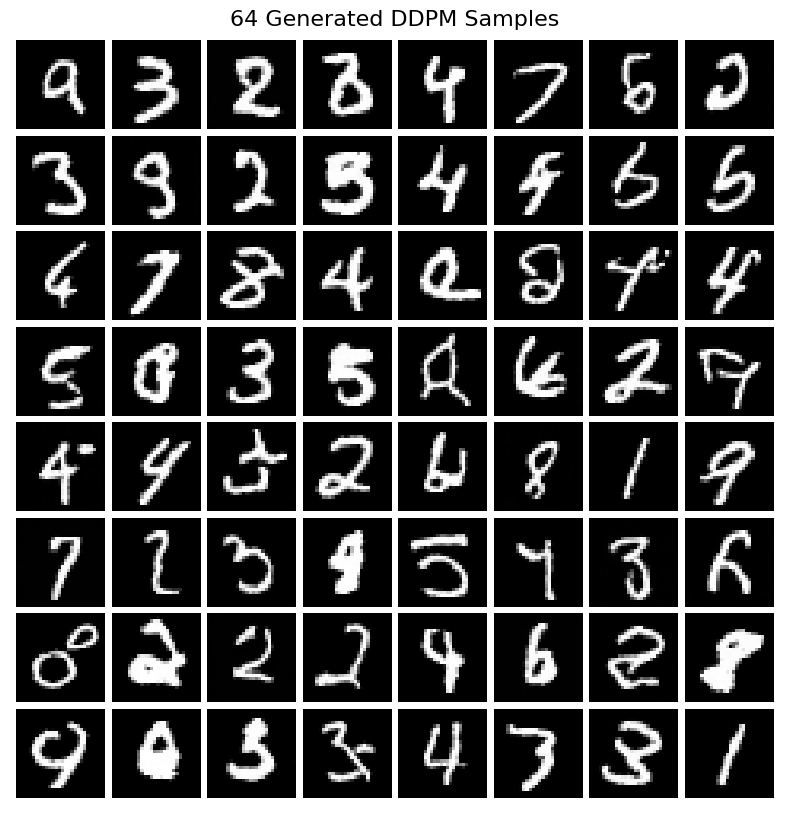

In [5]:
final_xi, intermediates, norms = ancestral_sample(model, diff, count=64, device=device)

final_xi = (final_xi + 1.0) / 2.0
final_xi = final_xi.clamp(0, 1)

grid = torchvision.utils.make_grid(final_xi, nrow=8, padding=2, pad_value=1.0)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("64 Generated DDPM Samples", fontsize=16)
plt.show()

# Denoising Trajectories

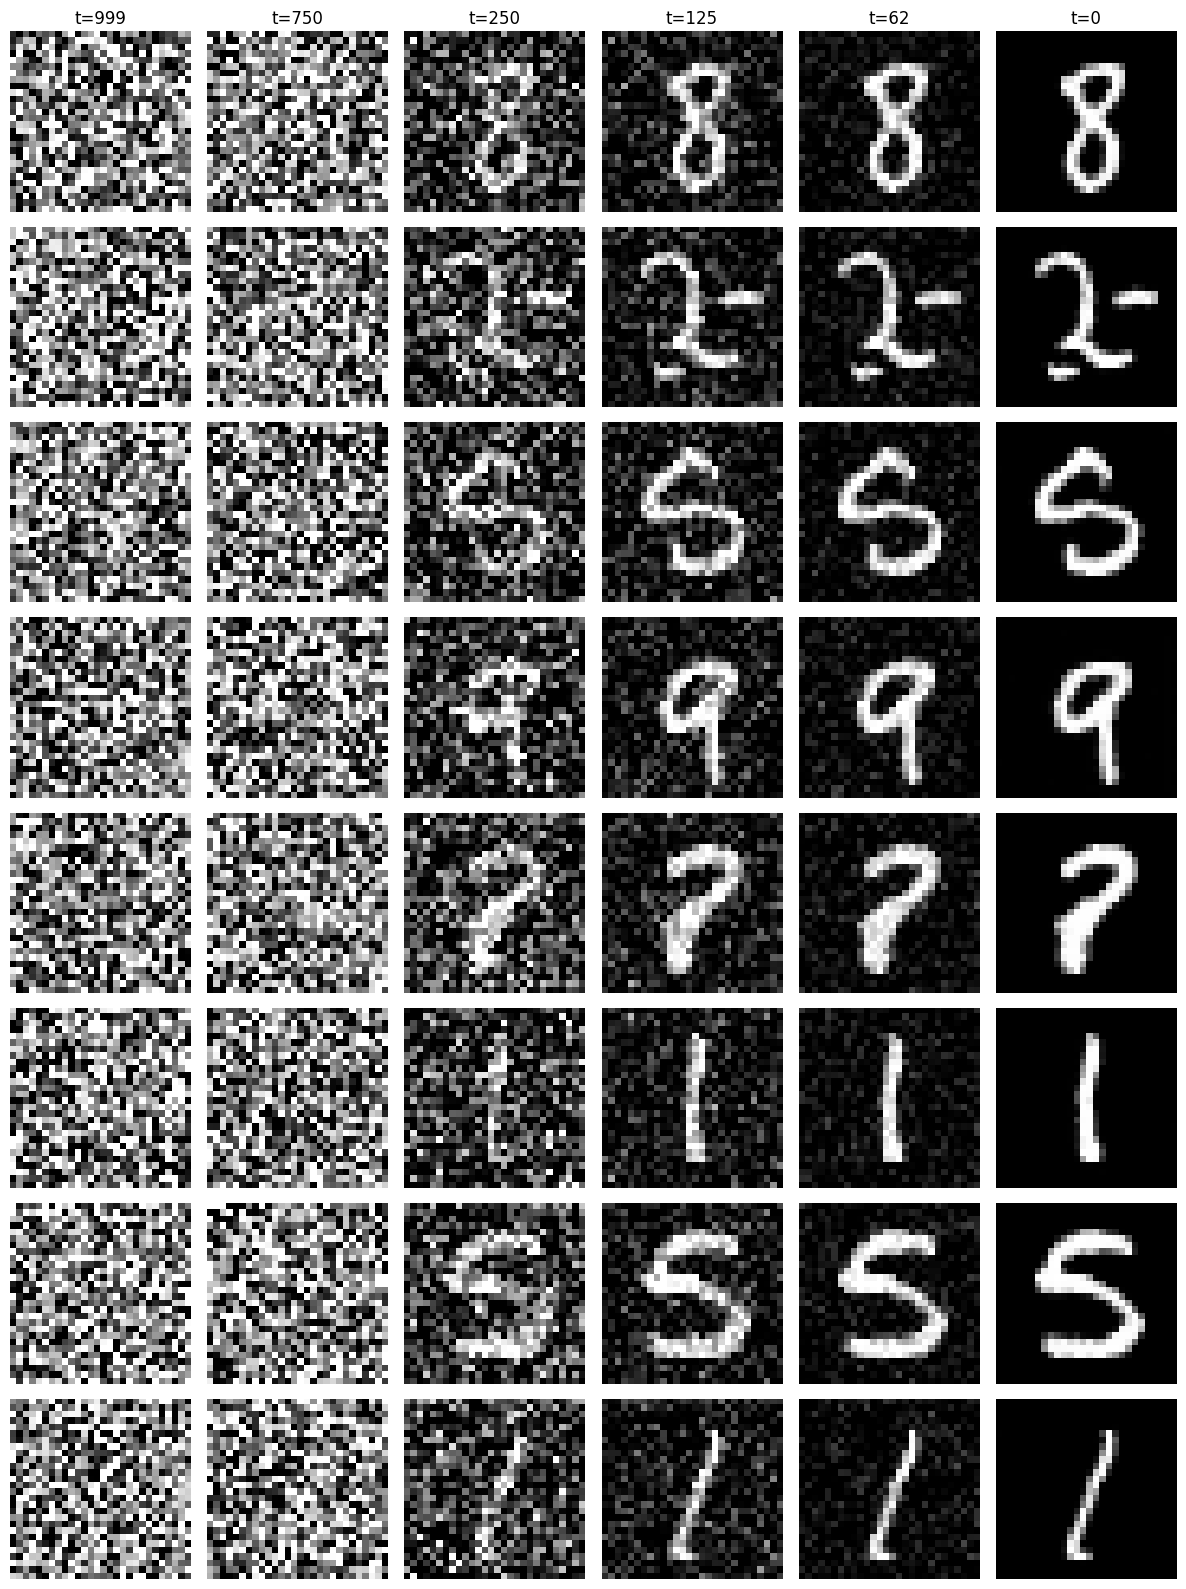

In [6]:
final_xi, intermediates, norms = ancestral_sample(model, diff, count=8, device=device)
plot_ancestral_samples(intermediates, count=8)

# Quantitative Evaluation

In [13]:
classifier = MNISTFeatureExtractor()
classifier.load_state_dict(torch.load("stats_models/mnist_classifier.pth", map_location=device))
classifier.to(device)

MNISTFeatureExtractor(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [14]:
real_features = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        _, feats = classifier(imgs)
        real_features.append(feats.cpu().numpy())
        if sum(len(b) for b in real_features) >= NUM_EVAL_SAMPLES:
            break
real_features = np.concatenate(real_features, axis=0)[:NUM_EVAL_SAMPLES]

fake_features = []
all_fake_images = []
preds = []
batch_size = 125
with torch.no_grad():
    for _ in range(0, NUM_EVAL_SAMPLES, batch_size):
        count = min(batch_size, NUM_EVAL_SAMPLES - _)
        fake_imgs = strided_ddim_sample(model, diff, count, device, stride=10)
        pred, feats = classifier(fake_imgs)
        preds.append(pred.cpu().numpy())
        fake_features.append(feats.cpu().numpy())
        all_fake_images.append(fake_imgs.cpu().numpy())
        torch.cuda.empty_cache()
fake_features = np.concatenate(fake_features, axis=0)
all_fake_images = np.concatenate(all_fake_images, axis=0)
preds = np.concatenate(preds, axis=0)

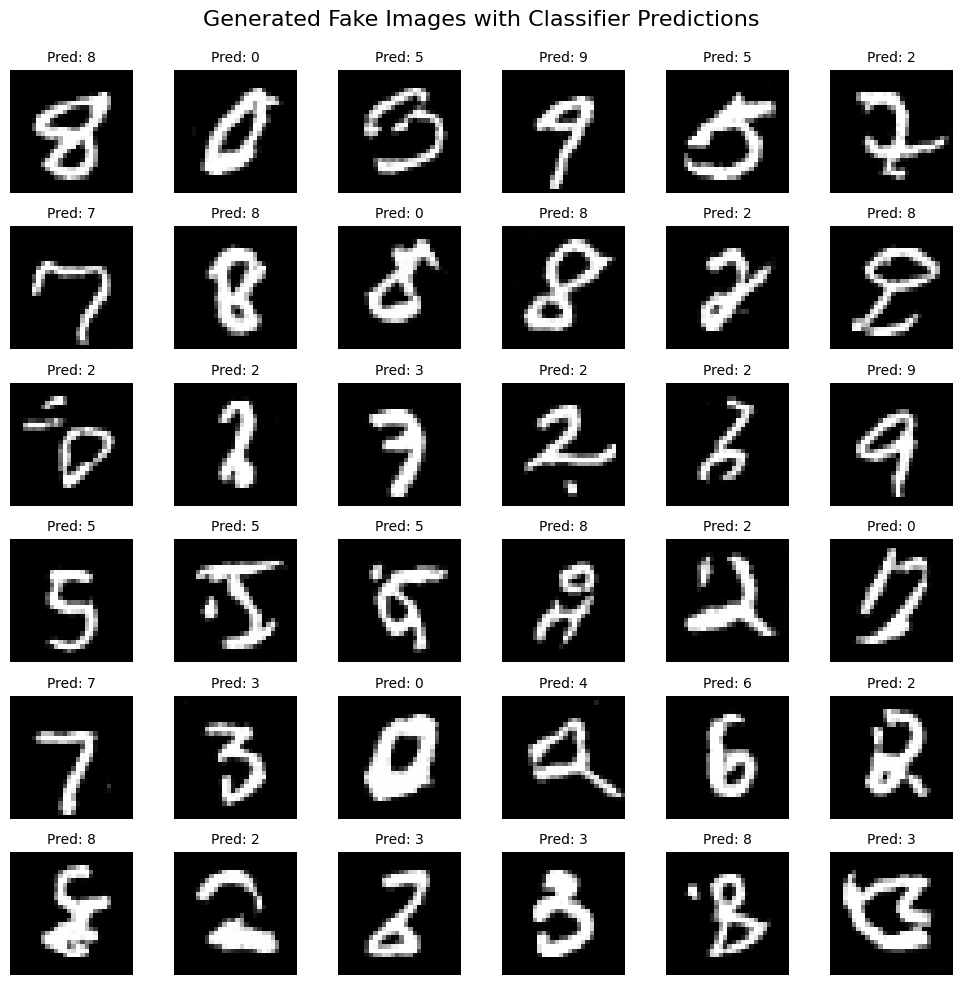

In [15]:
predicted_classes = np.argmax(preds, axis=1)
all_fake_images = (all_fake_images + 1.0) / 2.0
all_fake_images = np.clip(all_fake_images, 0, 1)

random_indices = np.random.choice(NUM_EVAL_SAMPLES, 36, replace=False)
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
fig.suptitle("Generated Fake Images with Classifier Predictions", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]
    img = all_fake_images[idx].squeeze() 
    label = predicted_classes[idx]
    
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {label}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [16]:
def calculate_fid(act1, act2):
    """Calculates the Frechet Inception Distance."""
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def calculate_kid(act1, act2, degree=3):
    """Calculates the Kernel Inception Distance using a polynomial kernel."""
    # Scale gamma appropriately for the feature dimension (128)
    gamma = 1.0 / act1.shape[1] 
    
    K_XX = polynomial_kernel(act1, act1, degree=degree, gamma=gamma, coef0=1)
    K_YY = polynomial_kernel(act2, act2, degree=degree, gamma=gamma, coef0=1)
    K_XY = polynomial_kernel(act1, act2, degree=degree, gamma=gamma, coef0=1)
    
    m, n = act1.shape[0], act2.shape[0]
    
    # Remove diagonal elements for unbiased intra-group estimation
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)
    
    kid = (K_XX.sum() / (m * (m - 1))) + (K_YY.sum() / (n * (n - 1))) - (2 * K_XY.mean())
    return kid

dataset_fid = calculate_fid(real_features, fake_features)
dataset_kid = calculate_kid(real_features, fake_features)

print(f"Dataset-FID Score: {dataset_fid:.4f}")
print(f"Dataset-KID Score: {dataset_kid:.5f}")

Dataset-FID Score: 82.0194
Dataset-KID Score: 113.82812


# Overfitting test

In [17]:
train_features = []
with torch.no_grad():
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        _, feats = classifier(imgs)
        train_features.append(feats.cpu().numpy())
        if sum(len(b) for b in train_features) >= NUM_EVAL_SAMPLES:
            break
train_features = np.concatenate(train_features, axis=0)[:NUM_EVAL_SAMPLES]

train_dataset_fid = calculate_fid(train_features, fake_features)
train_dataset_kid = calculate_kid(train_features, fake_features)

print(f"Dataset-FID Score: {dataset_fid:.4f} | Train-FID Score: {train_dataset_fid:.4f}")
print(f"Dataset-KID Score: {dataset_kid:.5f} | Train-KID Score: {train_dataset_kid:.5f}")

Dataset-FID Score: 82.0194 | Train-FID Score: 82.9887
Dataset-KID Score: 113.82812 | Train-KID Score: 113.61816
